変形開始
ノード数 = 80, 初期確率 p = 0.05, 段階数 = 10
[途中経過] 段階 1/10 : alpha=0.10
[途中経過] 段階 2/10 : alpha=0.20
[途中経過] 段階 3/10 : alpha=0.30
[途中経過] 段階 4/10 : alpha=0.40
[途中経過] 段階 5/10 : alpha=0.50
[途中経過] 段階 6/10 : alpha=0.60
[途中経過] 段階 7/10 : alpha=0.70
[途中経過] 段階 8/10 : alpha=0.80
[途中経過] 段階 9/10 : alpha=0.90
[途中経過] 段階 10/10 : alpha=1.00
描画開始: グラフ構造


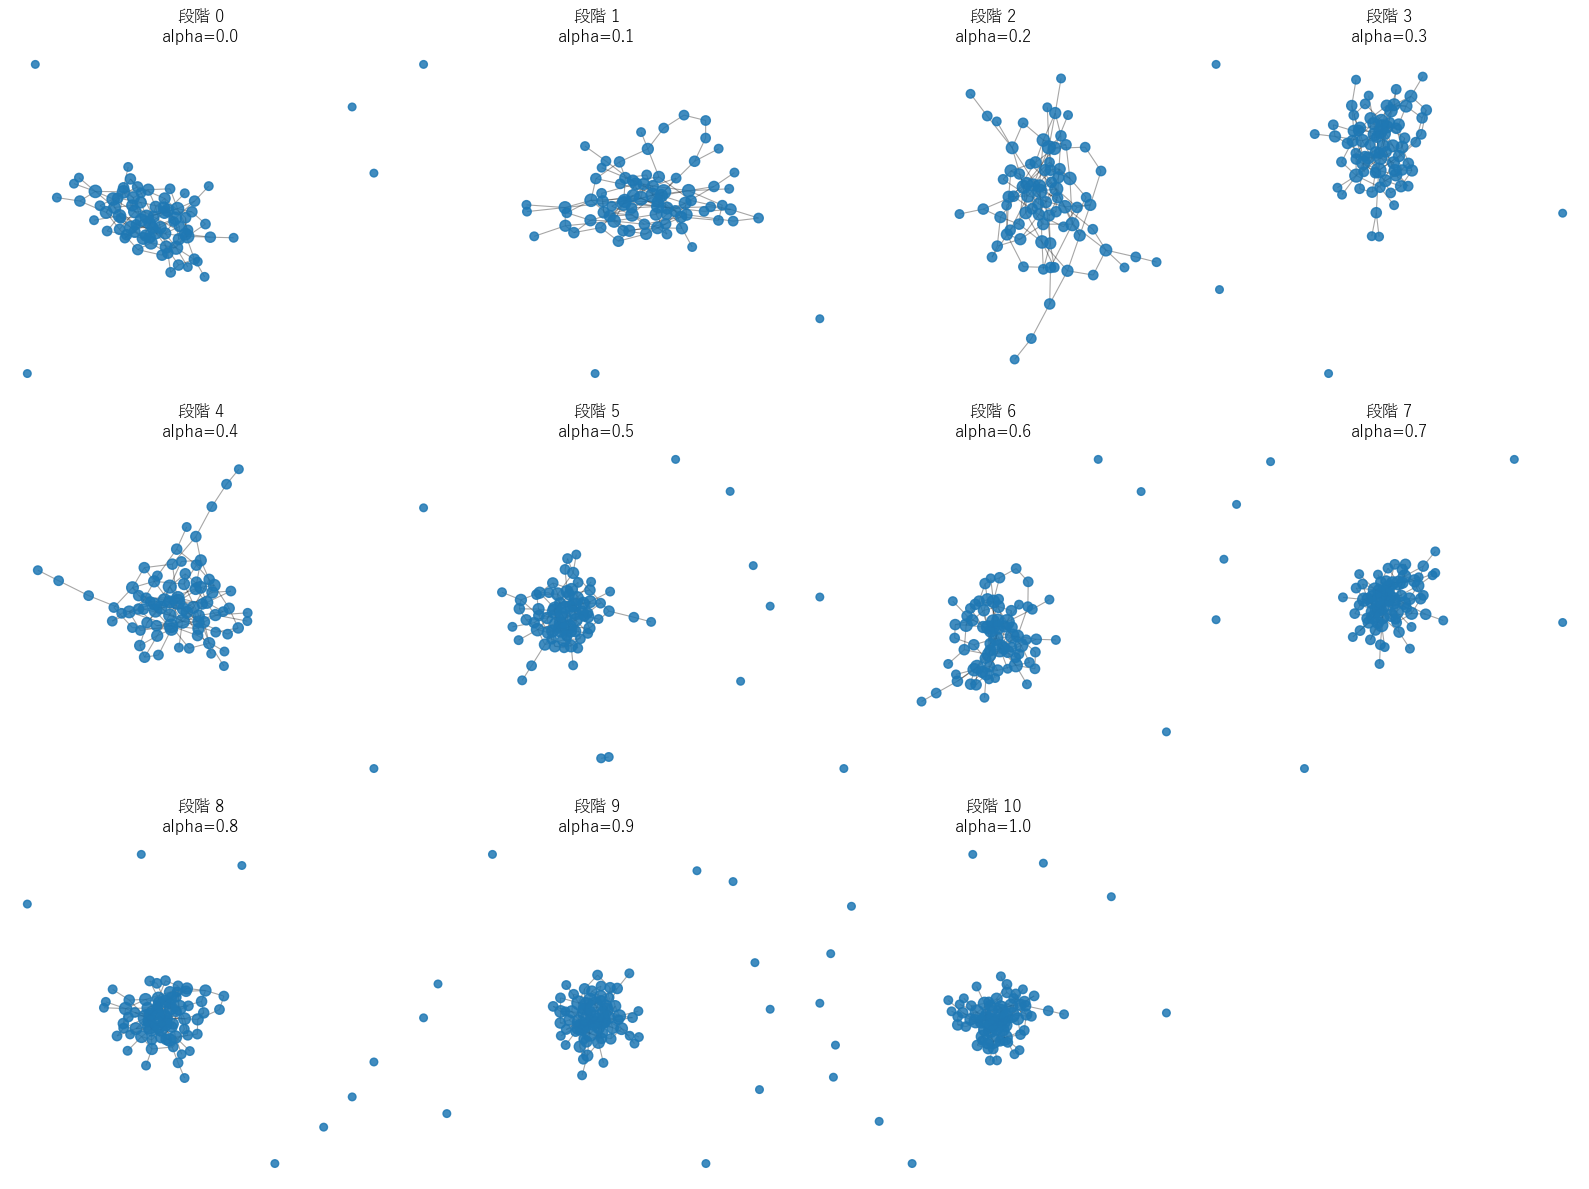

描画開始: 次数分布


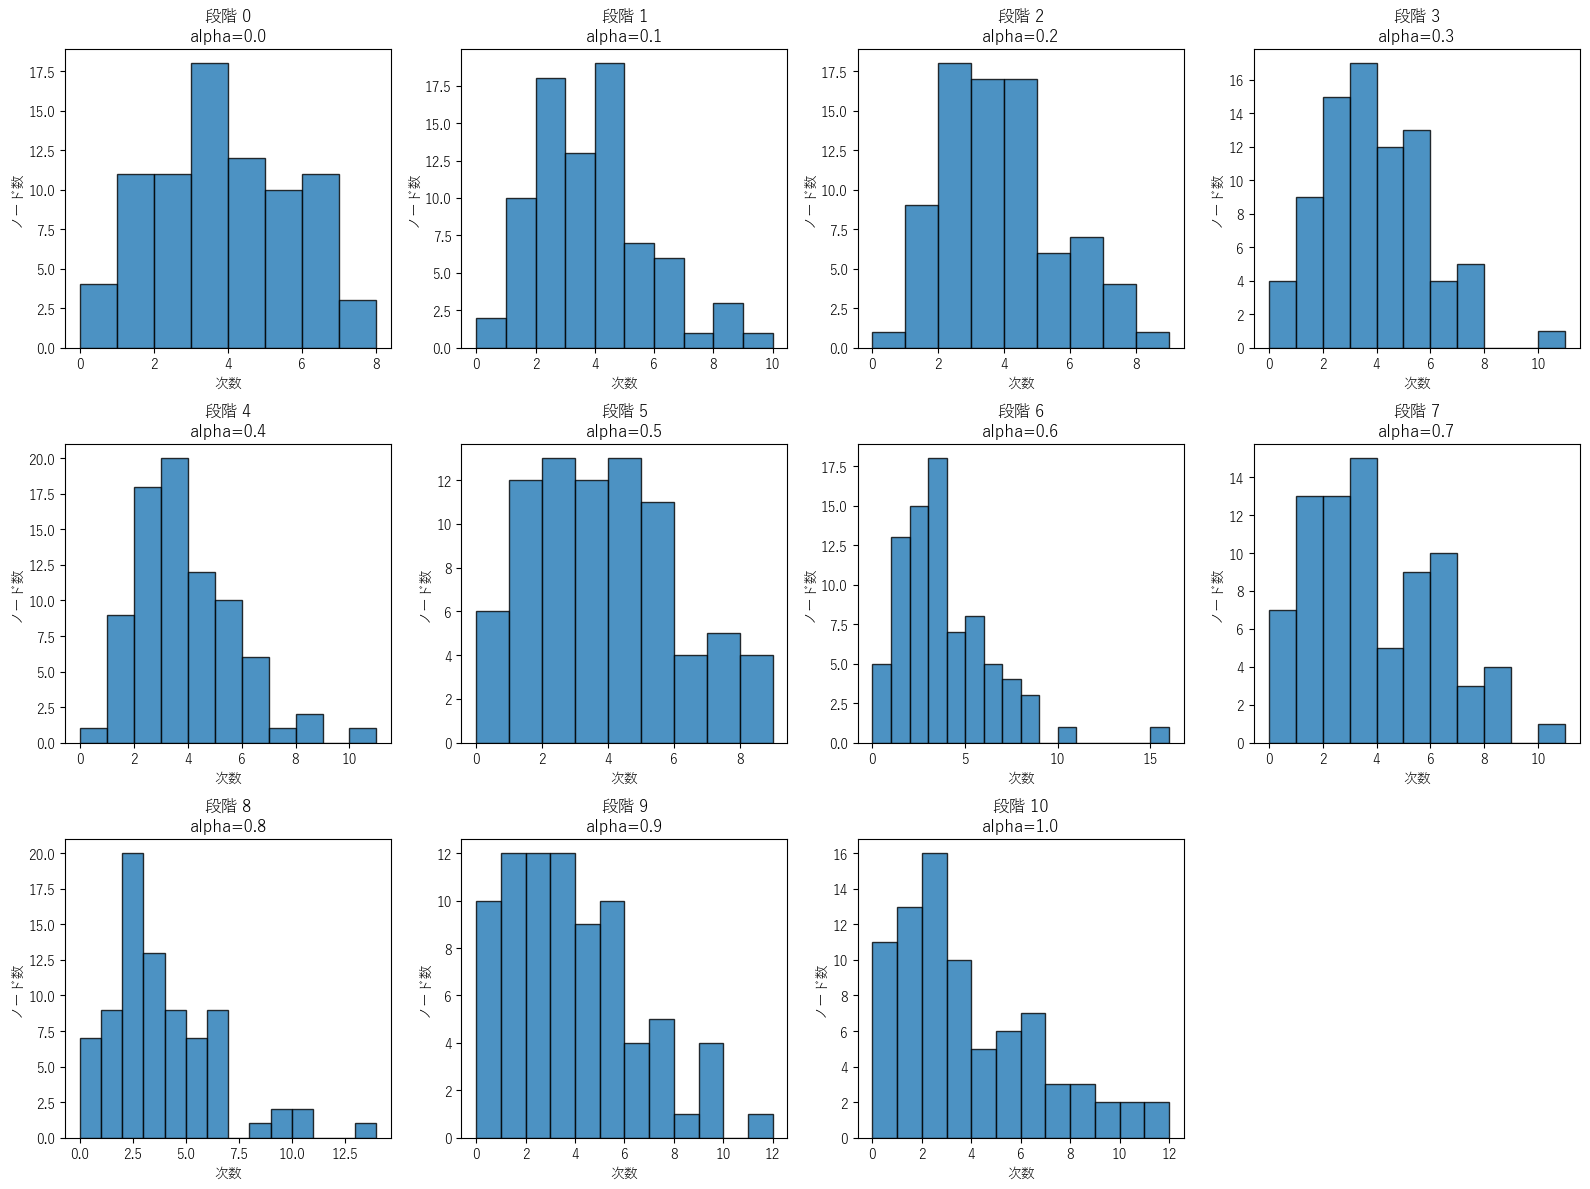

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.font_manager as fm


# =========================
# 日本語フォント設定
# =========================
def set_japanese_font():
    candidates = ["Yu Gothic", "MS Gothic", "Hiragino Sans", "IPAPGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for c in candidates:
        if c in available:
            plt.rcParams["font.family"] = c
            return
    # 見つからなければ英語フォントのまま
    print("[WARNING] 日本語フォントが見つかりません。必要ならタイトルを英語にしてください。")


set_japanese_font()


# =========================
# 基本設定
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# =========================
# ノード選択関数
# =========================
def choose_node_preferential(G):
    """
    次数に比例してノードを1つ選ぶ
    degree + 1 にして孤立ノードも選ばれるようにする
    """
    nodes = list(G.nodes())
    weights = np.array([G.degree(n) + 1 for n in nodes], dtype=float)
    weights /= weights.sum()
    return np.random.choice(nodes, p=weights)


def choose_node_uniform(G):
    """
    一様ランダムにノードを1つ選ぶ
    """
    return random.choice(list(G.nodes()))


def choose_node_mixed(G, alpha):
    """
    alpha=0 なら一様
    alpha=1 なら次数比例
    """
    if random.random() < alpha:
        return choose_node_preferential(G)
    else:
        return choose_node_uniform(G)


# =========================
# グラフ補間
# =========================
def rewire_graph_toward_scale_free(G, alpha, rewires_per_step=300):
    """
    G を少しずつスケールフリー寄りにする
    alpha が大きいほど、高次数ノードに辺が集まりやすい

    手順:
    - 既存の辺を1本選んで削除
    - 新しい2ノードを選んで辺を張る
    - そのとき endpoint の選び方を
      一様選択と次数比例選択で混合する
    """
    G = G.copy()
    nodes = list(G.nodes())

    for _ in range(rewires_per_step):
        edges = list(G.edges())
        if not edges:
            break

        # 辺を1本削除
        u_old, v_old = random.choice(edges)
        G.remove_edge(u_old, v_old)

        # 新しい辺を追加
        max_try = 100
        added = False

        for _ in range(max_try):
            u = choose_node_mixed(G, alpha)
            v = choose_node_mixed(G, alpha)

            if u == v:
                continue
            if G.has_edge(u, v):
                continue

            G.add_edge(u, v)
            added = True
            break

        # 万一追加失敗したら元に戻す
        if not added:
            if u_old != v_old and not G.has_edge(u_old, v_old):
                G.add_edge(u_old, v_old)

    return G


# =========================
# 可視化
# =========================
def plot_transition(graphs, alphas):
    ncols = 4
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        pos = nx.spring_layout(G, seed=SEED)

        degrees = np.array([G.degree(n) for n in G.nodes()])
        node_sizes = 30 + degrees * 8

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=node_sizes,
            alpha=0.85
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            alpha=0.35,
            width=0.8
        )

        ax.set_title(f"段階 {i}\nalpha={alpha:.1f}")
        ax.axis("off")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_degree_distributions(graphs, alphas):
    """
    各段階の次数分布も確認する
    """
    ncols = 4
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        deg = [G.degree(n) for n in G.nodes()]
        bins = range(0, max(deg) + 2)

        ax.hist(deg, bins=bins, edgecolor="black", alpha=0.8)
        ax.set_title(f"段階 {i}\nalpha={alpha:.1f}")
        ax.set_xlabel("次数")
        ax.set_ylabel("ノード数")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# メイン
# =========================
def main():
    n = 80
    p = 0.05
    steps = 10
    rewires_per_step = 500

    # 初期グラフ: 均一ランダムグラフ
    G = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

    graphs = [G.copy()]
    alphas = [0.0]

    print("変形開始")
    print(f"ノード数 = {n}, 初期確率 p = {p}, 段階数 = {steps}")

    for step in range(1, steps + 1):
        alpha = step / steps
        print(f"[途中経過] 段階 {step}/{steps} : alpha={alpha:.2f}")

        G = rewire_graph_toward_scale_free(
            G,
            alpha=alpha,
            rewires_per_step=rewires_per_step
        )

        graphs.append(G.copy())
        alphas.append(alpha)

    print("描画開始: グラフ構造")
    plot_transition(graphs, alphas)

    print("描画開始: 次数分布")
    plot_degree_distributions(graphs, alphas)


if __name__ == "__main__":
    main()